# Document Layout Classification — Modelling

This notebook builds and evaluates a CNN-based document image classifier using transfer learning with ResNet18.

**Dataset:** 165 scanned document images across 3 classes — email, resume, and scientific publication.

**Approach:** Transfer learning — ResNet18 pre-trained on ImageNet, with the final layer replaced and retrained for 3-class document classification.

**Steps:**
1. Data loading, transforms and augmentation
2. Custom Dataset and DataLoader setup
3. Model architecture — ResNet18 with transfer learning
4. Training loop with train/validation monitoring
5. Test set evaluation — accuracy, classification report, confusion matrix
6. Prediction visualisation

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pandas as pd
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

print(f'PyTorch version: {torch.__version__}')
print(f'GPU available: {torch.cuda.is_available()}')

PyTorch version: 2.10.0+cpu
GPU available: False


In [2]:
# Configuration — putting all key settings in one place
DATA_DIR = '../data'
CLASSES = ['email', 'resume', 'scientific_publication']
IMG_SIZE = 224          # ResNet expects 224x224 input
BATCH_SIZE = 16         # Number of images processed at once during training
NUM_EPOCHS = 15         # Number of times the model sees the full training set
LEARNING_RATE = 0.001   # How fast the model updates its weights
NUM_CLASSES = 3         
RANDOM_SEED = 42

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [3]:
# Define image transformations
# Training: apply augmentation to artificially increase dataset variety
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation/test: no augmentation, just resize and normalise
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print('Transforms defined.')

Transforms defined.


In [4]:
# Custom Dataset class
class DocumentDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img = Image.open(self.file_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

print('Dataset class defined.')

Dataset class defined.


In [5]:
# Build file paths and labels for all images
file_paths = []
labels = []

for label_idx, cls in enumerate(CLASSES):
    cls_dir = os.path.join(DATA_DIR, cls)
    for img_name in os.listdir(cls_dir):
        file_paths.append(os.path.join(cls_dir, img_name))
        labels.append(label_idx)

print(f'Total images: {len(file_paths)}')
print(f'Label mapping:')
for i, cls in enumerate(CLASSES):
    print(f'  {i} → {cls}')

Total images: 165
Label mapping:
  0 → email
  1 → resume
  2 → scientific_publication


In [6]:
# Split data into train, validation and test sets (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    file_paths, labels, test_size=0.3, random_state=RANDOM_SEED, stratify=labels)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED, stratify=y_temp)

print(f'Training set:   {len(X_train)} images')
print(f'Validation set: {len(X_val)} images')
print(f'Test set:       {len(X_test)} images')

Training set:   115 images
Validation set: 25 images
Test set:       25 images


In [7]:
# Create Dataset objects and DataLoaders
train_dataset = DocumentDataset(X_train, y_train, transform=train_transforms)
val_dataset   = DocumentDataset(X_val, y_val, transform=val_transforms)
test_dataset  = DocumentDataset(X_test, y_test, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches:      {len(train_loader)}')
print(f'Validation batches: {len(val_loader)}')
print(f'Test batches:       {len(test_loader)}')

Train batches:      8
Validation batches: 2
Test batches:       2


In [8]:
# Load pre-trained ResNet18 and adapt for the 3 classes
model = models.resnet18(weights='IMAGENET1K_V1')

# Freeze all layers — so as not to retrain the whole network
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer with one for 3 classes
# This is the only layer that will be trained
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

model = model.to(device)

print('Model loaded.')
print(f'Output layer: {model.fc}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\oluwa/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|█████████████████████████████████████| 44.7M/44.7M [00:05<00:00, 9.33MB/s]


Model loaded.
Output layer: Linear(in_features=512, out_features=3, bias=True)


In [9]:
# Define loss function and optimiser
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)

print('Loss function: CrossEntropyLoss')
print(f'Optimiser: Adam (lr={LEARNING_RATE})')

Loss function: CrossEntropyLoss
Optimiser: Adam (lr=0.001)


In [10]:
# Training loop
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(NUM_EPOCHS):
    # --- Training phase ---
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()           # Clear gradients from previous step
        outputs = model(images)         # Forward pass
        loss = criterion(outputs, labels)  # Calculate loss
        loss.backward()                 # Backward pass (calculate gradients)
        optimizer.step()                # Update weights

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc  = correct / total

    # --- Validation phase ---
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc  = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f'Epoch {epoch+1:02d}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

Epoch 01/15 | Train Loss: 1.1724 | Train Acc: 0.3739 | Val Loss: 1.0705 | Val Acc: 0.4400
Epoch 02/15 | Train Loss: 0.9838 | Train Acc: 0.5043 | Val Loss: 0.9209 | Val Acc: 0.6400
Epoch 03/15 | Train Loss: 0.8479 | Train Acc: 0.6609 | Val Loss: 0.9942 | Val Acc: 0.6000
Epoch 04/15 | Train Loss: 0.7637 | Train Acc: 0.6870 | Val Loss: 0.8314 | Val Acc: 0.6800
Epoch 05/15 | Train Loss: 0.6783 | Train Acc: 0.8087 | Val Loss: 0.7893 | Val Acc: 0.6000
Epoch 06/15 | Train Loss: 0.7270 | Train Acc: 0.7217 | Val Loss: 0.7856 | Val Acc: 0.6400
Epoch 07/15 | Train Loss: 0.6088 | Train Acc: 0.7739 | Val Loss: 0.6615 | Val Acc: 0.7600
Epoch 08/15 | Train Loss: 0.5932 | Train Acc: 0.7652 | Val Loss: 0.6321 | Val Acc: 0.7200
Epoch 09/15 | Train Loss: 0.6653 | Train Acc: 0.7913 | Val Loss: 0.5986 | Val Acc: 0.7600
Epoch 10/15 | Train Loss: 0.5736 | Train Acc: 0.7826 | Val Loss: 0.5859 | Val Acc: 0.8800
Epoch 11/15 | Train Loss: 0.5216 | Train Acc: 0.8348 | Val Loss: 0.5455 | Val Acc: 0.7600
Epoch 12/1

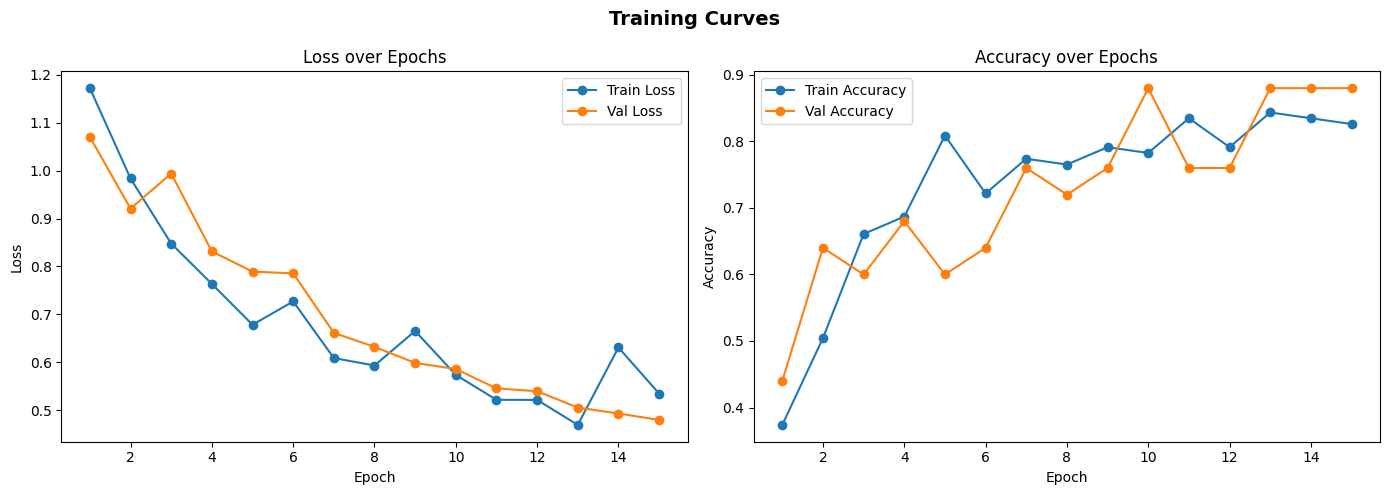

In [11]:
# Plot training and validation loss and accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(range(1, NUM_EPOCHS+1), train_losses, label='Train Loss', marker='o')
axes[0].plot(range(1, NUM_EPOCHS+1), val_losses, label='Val Loss', marker='o')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy curves
axes[1].plot(range(1, NUM_EPOCHS+1), train_accs, label='Train Accuracy', marker='o')
axes[1].plot(range(1, NUM_EPOCHS+1), val_accs, label='Val Accuracy', marker='o')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Final evaluation on test set
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print('Test Set Results:')
print(f'Accuracy: {sum(p==l for p,l in zip(all_preds, all_labels)) / len(all_labels):.4f}')
print()
print(classification_report(all_labels, all_preds, target_names=CLASSES))

Test Set Results:
Accuracy: 0.8400

                        precision    recall  f1-score   support

                 email       0.89      1.00      0.94         8
                resume       0.86      0.67      0.75         9
scientific_publication       0.78      0.88      0.82         8

              accuracy                           0.84        25
             macro avg       0.84      0.85      0.84        25
          weighted avg       0.84      0.84      0.83        25



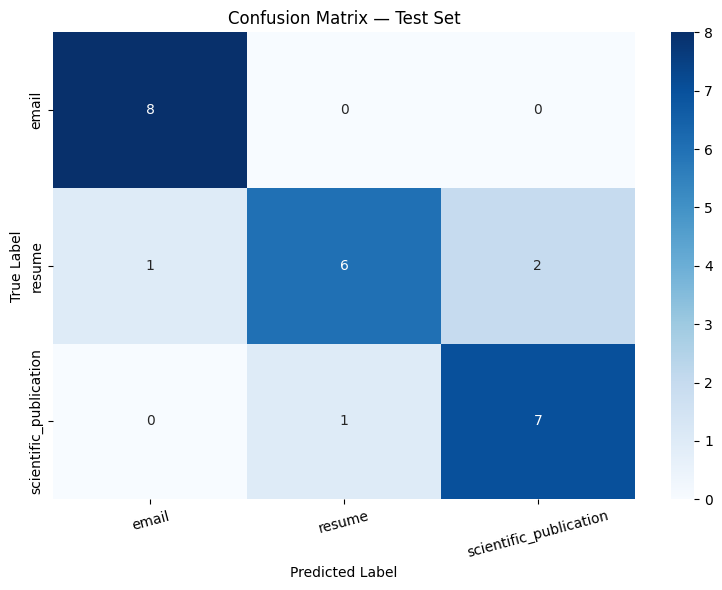

In [13]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

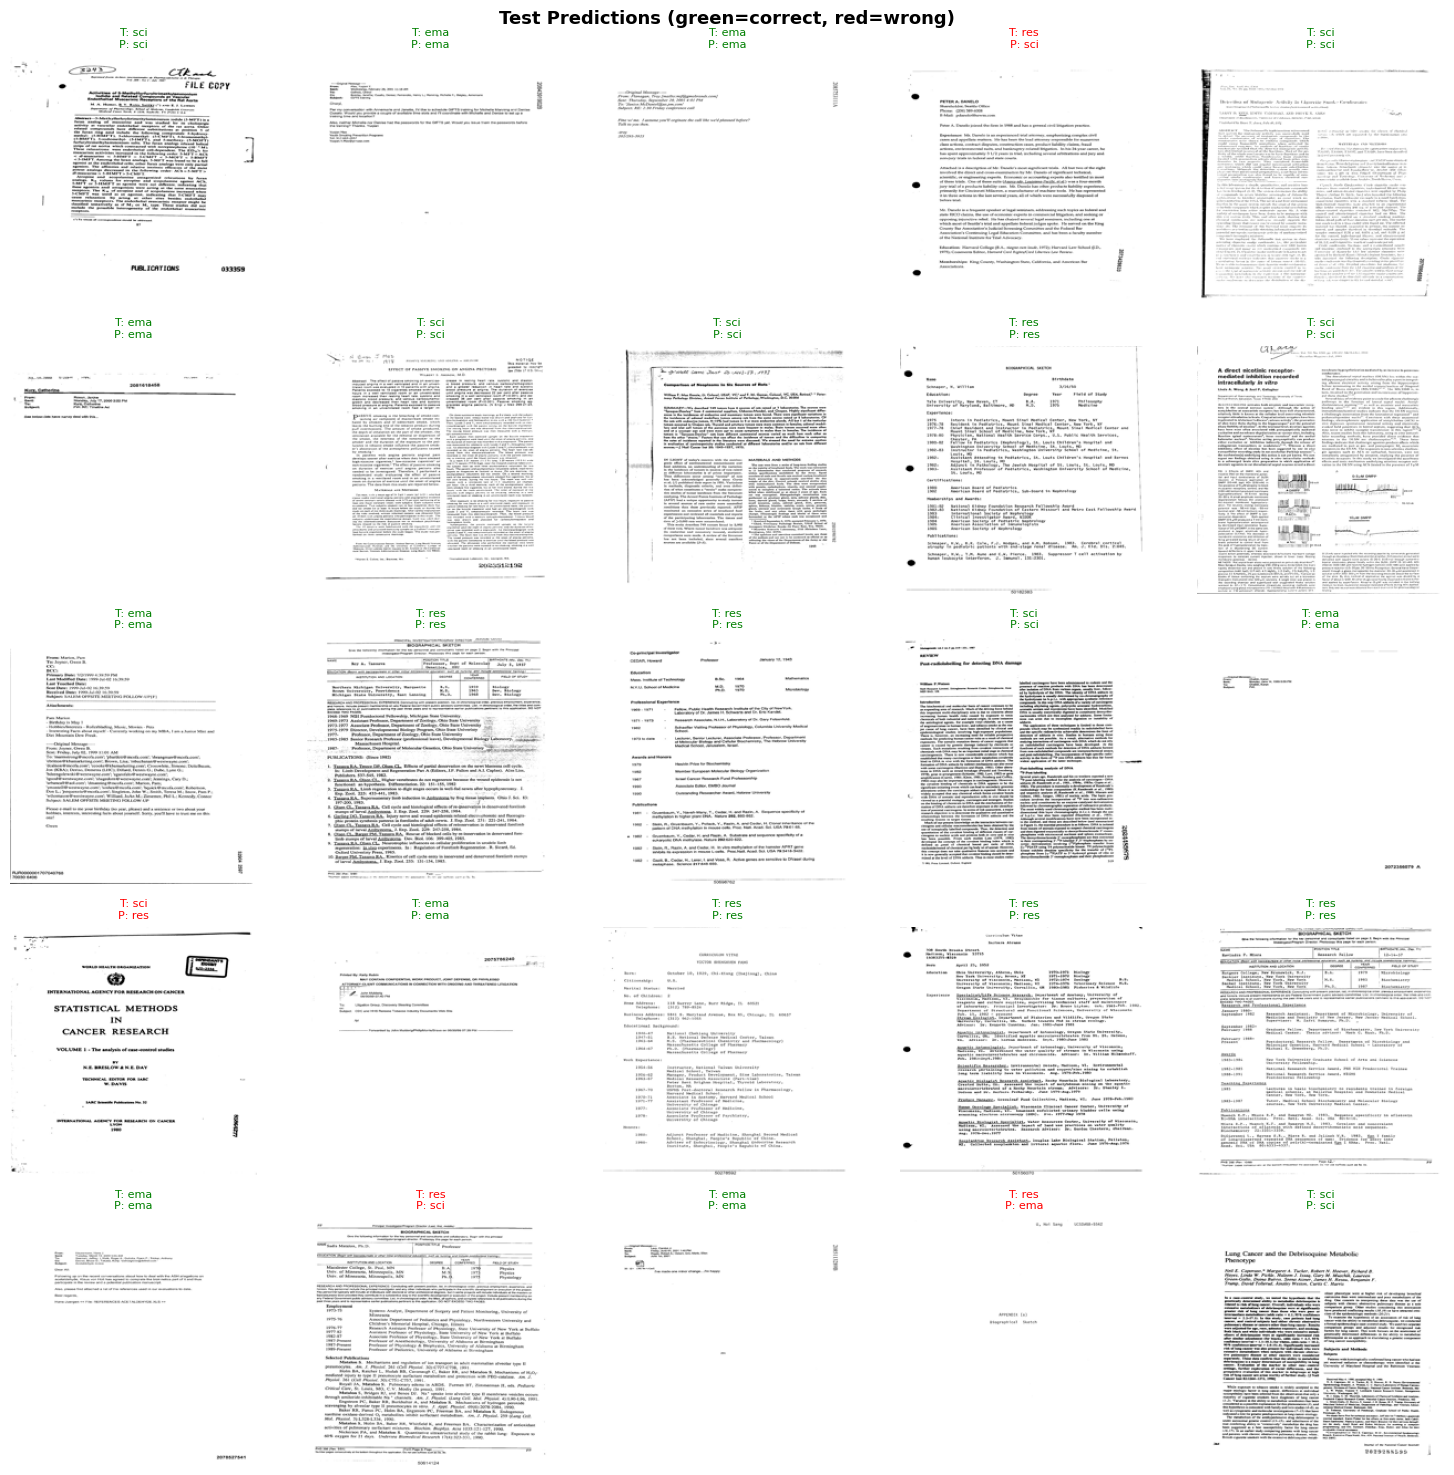

In [14]:
# Visualise predictions on test images
class_names = CLASSES
fig, axes = plt.subplots(5, 5, figsize=(15, 15))
axes = axes.flatten()

test_dataset_vis = DocumentDataset(X_test, y_test, transform=val_transforms)

model.eval()
with torch.no_grad():
    for i in range(len(X_test)):
        img_original = Image.open(X_test[i]).convert('RGB').resize((224, 224))
        img_tensor, label = test_dataset_vis[i]
        output = model(img_tensor.unsqueeze(0).to(device))
        pred = torch.max(output, 1)[1].item()

        axes[i].imshow(img_original)
        axes[i].axis('off')
        color = 'green' if pred == label else 'red'
        axes[i].set_title(f'T: {class_names[label][:3]}\nP: {class_names[pred][:3]}',
                          fontsize=8, color=color)

plt.suptitle('Test Predictions (green=correct, red=wrong)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Save the trained model
torch.save(model.state_dict(), '../models/resnet18_document_classifier.pth')
print('Model saved.')

Model saved.


## Results Summary

| Metric | Score |
|--------|-------|
| Test Accuracy | 84% |
| Email F1 | 0.94 |
| Resume F1 | 0.75 |
| Scientific Publication F1 | 0.82 |
| Macro Average F1 | 0.84 |

## Key Findings

- **Transfer learning is highly effective with small datasets** — ResNet18 pre-trained on ImageNet achieved 84% accuracy on just 165 images with no GPU
- **Email is the easiest class to identify** (F1=0.94) — consistent with EDA showing emails have the most distinct visual appearance (high brightness, lots of whitespace)
- **Resume/scientific publication confusion is the main error** — both classes share dense, structured text layouts making them visually similar
- **No overfitting observed** — validation accuracy tracked closely with training accuracy throughout, suggesting the augmentation strategy was effective

## Potential Improvements

- Collect more training data — 55 images per class is very small; 500+ would significantly improve performance
- Fine-tune deeper layers of ResNet rather than just the final layer
- Try a larger model such as ResNet50 or EfficientNet
- Use test-time augmentation to improve prediction confidence